In [5]:
# ============================================
# 1. Import Libraries
# ============================================
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [6]:
# ============================================
# 2. Load Data from CSV
# ============================================
df = pd.read_csv('../data/cleaned/sales_cleaned.csv')

print("✅ Data loaded successfully!")
print(f"Total rows: {len(df)}")

✅ Data loaded successfully!
Total rows: 32348


In [7]:
# ============================================
# 3. Data Preparation (Traditional Analysis)
# ============================================
# Calculate revenue per row
df['revenue'] = df['quantity'] * df['unit_price']

# Aggregate daily sales
daily_sales = df.groupby('sale_date').agg({
    'revenue': 'sum',
    'quantity': 'sum',
    'discount_percent': 'mean',
    'unit_price': 'mean'
}).reset_index()

# Convert date to numerical features
daily_sales['sale_date'] = pd.to_datetime(daily_sales['sale_date'])
daily_sales['day_of_week'] = daily_sales['sale_date'].dt.dayofweek
daily_sales['month'] = daily_sales['sale_date'].dt.month
daily_sales['day_of_year'] = daily_sales['sale_date'].dt.dayofyear

# Select features and target
features = ['day_of_week', 'month', 'day_of_year', 'quantity', 'discount_percent', 'unit_price']
target = 'revenue'

X = daily_sales[features]
y = daily_sales[target]

print("✅ Daily sales data prepared.")
print(f"Total days: {len(daily_sales)}")


✅ Daily sales data prepared.
Total days: 363


In [8]:
# ============================================
# 4. Train/Test Split (Traditional)
# ============================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Data split: {len(X_train)} train, {len(X_test)} test")


✅ Data split: 290 train, 73 test


In [9]:
# ============================================
# 5. AI Model Training (Machine Learning)
# ============================================
# Create and train the Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("✅ Model training completed.")

✅ Model training completed.


In [10]:
# ============================================
# 6. AI Model Evaluation (Machine Learning)
# ============================================
# Make predictions
y_pred = model.predict(X_test)

# Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"✅ Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:,.0f}")
print(f"R² Score: {r2:.2f}")

✅ Model Evaluation:
Mean Absolute Error (MAE): 8,585,182
R² Score: 0.95


✅ Feature Importance:
            feature  importance
3          quantity    0.834099
5        unit_price    0.143439
4  discount_percent    0.008217
2       day_of_year    0.005975
0       day_of_week    0.004512
1             month    0.003758


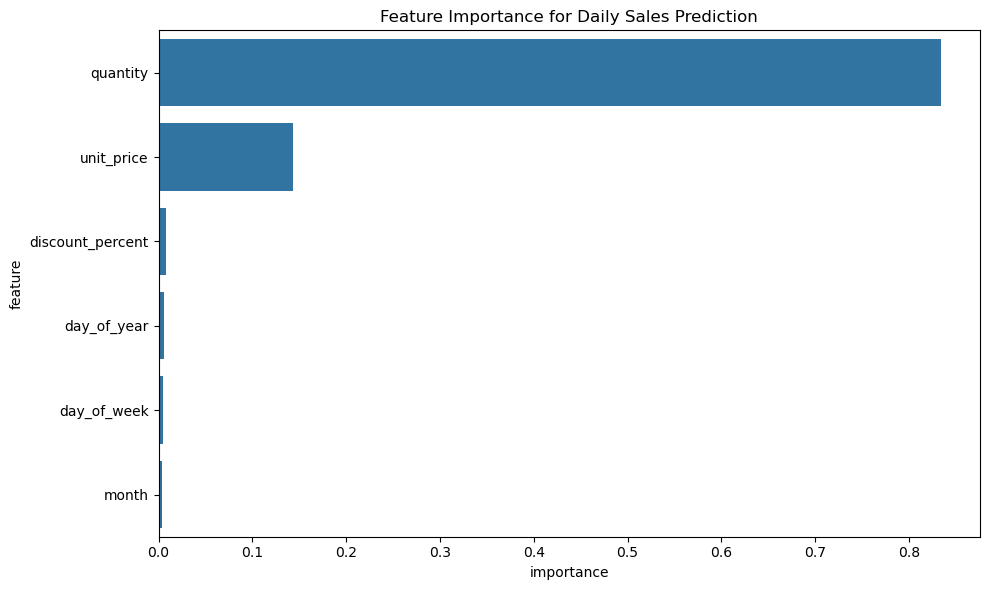

In [11]:
# ============================================
# 7. AI Feature Importance (Machine Learning)
# ============================================
# Show which features are most important
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("✅ Feature Importance:")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Feature Importance for Daily Sales Prediction')
plt.tight_layout()
plt.show()


In [12]:
# ============================================
# 8. Save Model for Later Use (AI)
# ============================================
joblib.dump(model, 'daily_sales_model.pkl')
print("✅ Model saved as: daily_sales_model.pkl")

✅ Model saved as: daily_sales_model.pkl


In [21]:
# ============================================
# 9. Predict Quantity for Tomorrow (NEW)
# ============================================

# 8.1 Prepare data for quantity prediction
X_quant = daily_sales[['day_of_week', 'month', 'day_of_year', 'discount_percent', 'unit_price']]
y_quant = daily_sales['quantity']

# 8.2 Split data
X_quant_train, X_quant_test, y_quant_train, y_quant_test = train_test_split(
    X_quant, y_quant, test_size=0.2, random_state=42
)

# 8.3 Train the quantity model
model_quant = RandomForestRegressor(n_estimators=100, random_state=42)
model_quant.fit(X_quant_train, y_quant_train)

# 8.4 Predict quantity for tomorrow
future_features = pd.DataFrame([[3, 6, 180, 12, 150]],columns=['day_of_week','month','day_of_year','discount_percent','unit_price'] # [day_of_week, month, day_of_year, discount_percent, unit_price]
                              )
quantity_tomorrow = model_quant.predict(future_features)[0]

print(f"🔮 Predicted quantity for tomorrow: {quantity_tomorrow:.0f}")

🔮 Predicted quantity for tomorrow: 293


In [22]:
# ============================================
# 10. Predict Future Sales (Using the predicted quantity)
# ============================================

# Now use the predicted quantity to predict sales
future_sales_features = pd.DataFrame([[3, 6, 180, quantity_tomorrow, 12, 150]],columns=['day_of_week','month','day_of_year','quantity','discount_percent','unit_price'] # [day_of_week, month, day_of_year, quantity, discount_percent, unit_price]
                                    )
future_sales = model.predict(future_sales_features)

print(f"🔮 Predicted sales for tomorrow: {future_sales[0]:,.0f}")

🔮 Predicted sales for tomorrow: 168,115,316
